# **Import Libraries**

In [1]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# GWR libraries (FIXED)
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import libpysal

# **Mount The Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Dataset**

In [3]:
# ===============================
# 2. LOAD DATASET
# ===============================
df = pd.read_csv("/content/drive/MyDrive/Data Science Group Project/Dataset.csv", encoding="latin1")

print(df.head())
print(df.info())

         ID                               Name Price Discounts Translation  \
0  11759683         Terrel Residencies Gal Oya   NaN       NaN         NaN   
1  15141529                     Lake Jay Hotel   NaN       NaN         NaN   
2   3965765                  Rathnapriya Oasis   NaN       NaN         NaN   
3  14787795                  ayaan group house   NaN       NaN         NaN   
4  14260533  Rajawewa Resort - Hotel in Ampara   NaN       NaN         NaN   

  Meal Plan Beds Info Message Rating Rating Stars Review Count Location  \
0       NaN       NaN     NaN    9.6          NaN            7   Ampara   
1       NaN       NaN     NaN      6          NaN            1   Ampara   
2       NaN       NaN     NaN    8.8            4          139   Ampara   
3       NaN       NaN     NaN      9          NaN            1   Ampara   
4       NaN       NaN     NaN    9.5          NaN            2   Ampara   

           Main Distance  Public Transport Distance Is Closed Is SoldOut  \
0   

# **Exploratory Data Analysis (EDA)**

ID                            249
Name                          219
Price                        1150
Discounts                    2044
Translation                  2156
Meal Plan                    2156
Beds Info                    2157
Message                      2156
Rating                       1767
Rating Stars                 1947
Review Count                 1767
Location                     1706
Main Distance                1706
Public Transport Distance    2165
Is Closed                    1706
Is SoldOut                   1706
Scraped At                   1706
dtype: int64


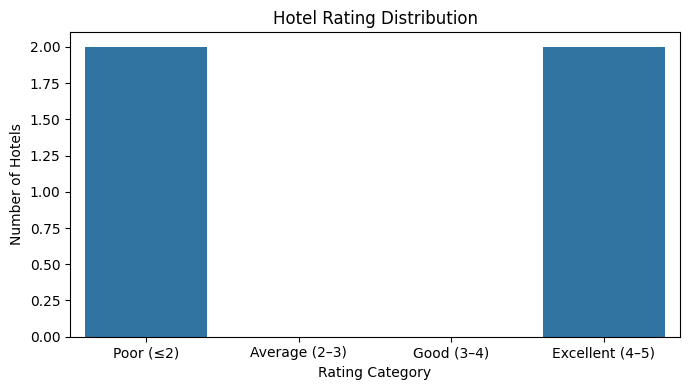

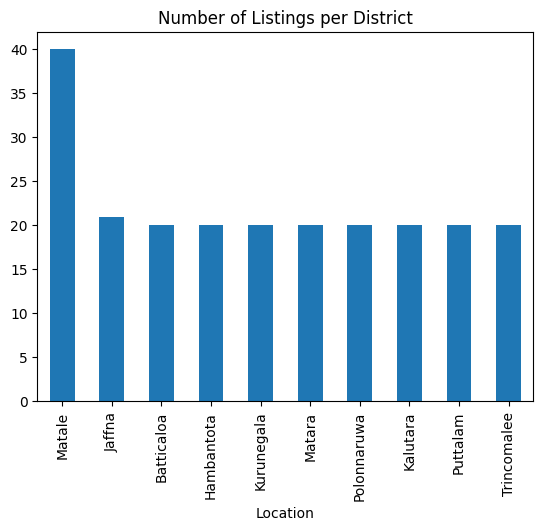

In [4]:
# ===============================
# 3. EDA
# ===============================

# Check missing values
print(df.isnull().sum())

# Distribution of ratings
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Create rating categories
df["Rating_Bin"] = pd.cut(
    df["Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["Poor (≤2)", "Average (2–3)", "Good (3–4)", "Excellent (4–5)"]
)
plt.figure(figsize=(7,4))
sns.countplot(x="Rating_Bin", data=df)
plt.title("Hotel Rating Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Hotels")
plt.tight_layout()
plt.show()


# Listings per district
df["Location"].value_counts().head(10).plot(kind="bar")
plt.title("Number of Listings per District")
plt.show()